# XAI-project — Evaluación robusta de L2 (clase rara) + proxy L1→L2

**Course:** INF-473 Explainable AI · UTFSM · Prof. Raquel Pezoa Rivera
**Authors:** Eduardo Morales · Octavia Jara · Benjamín Reyes

**Notebook:** `modeling/03_l2_robust_eval` — evaluación honesta de L2 (~11 positivos) y test de si L1 (área) sirve de proxy de L2 (intensidad): CV estratificada repetida con IC, Leave-One-Positive-Out y métricas por ranking. Escribe `eda/L2_Robust_Eval_Report.html` y muestra las figuras inline.

> Requiere `data/processed/conaf_enriched_2012_2018.parquet`. Ver [`README.md`](../README.md).

In [1]:
%matplotlib inline
import base64
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import BASE_DIR, DATA_PROCESSED  # noqa: E402
from src.modeling_features import (  # noqa: E402
    FEATURE_COLS,
    MEGAFIRE_HA_THRESHOLD,
    N_SPLITS,
    RANDOM_STATE,
    STUDY_REGIONS,
    XGB_PARAMS,
)

DATA = DATA_PROCESSED / "conaf_enriched_2012_2018.parquet"
OUT_HTML = BASE_DIR / "eda" / "L2_Robust_Eval_Report.html"

N_REPEATS = 20
MEGAFIRE_HA = MEGAFIRE_HA_THRESHOLD


def load():
    """Carga el dataset 2012-2018 y prepara features, etiquetas y columnas usables.

    Deriva las columnas temporales, codifica las categóricas a enteros, fuerza las
    features a numérico y descarta filas sin target/label_l2 o sin features válidas.

    Returns:
        Tupla ``(df, cols)`` con el DataFrame filtrado y la lista de columnas de
        features presentes y no totalmente nulas.
    """
    df = pd.read_parquet(DATA)
    df = df[df["region"].astype(str).isin(STUDY_REGIONS)].copy()
    ts = pd.to_datetime(df["fecha_hora_inicio"], errors="coerce")
    df["month"], df["hour"], df["day_of_year"] = ts.dt.month, ts.dt.hour, ts.dt.dayofyear
    df["region_name"] = df["region"].astype(str)
    for c in ["region", "provincia", "comuna"]:
        df[c] = pd.Categorical(df[c]).codes
    cols = [c for c in FEATURE_COLS if c in df.columns]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    cols = [c for c in cols if not df[c].isna().all()]
    df["label_l1"] = (df["superficie_quemada_total_ha"] >= MEGAFIRE_HA).astype(int)
    df = df.dropna(subset=["superficie_quemada_total_ha", "label_l2"] + cols).copy().reset_index(drop=True)
    return df, cols


def make_model(y):
    """Crea un XGBClassifier con ``scale_pos_weight`` ajustado a la clase rara.

    Args:
        y: Vector de etiquetas binarias del conjunto de entrenamiento.

    Returns:
        Clasificador XGBoost sin entrenar, con los hiperparámetros compartidos.
    """
    spw = (len(y) - y.sum()) / max(y.sum(), 1)
    return xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw)


def repeated_cv(X, y):
    """Ejecuta validación cruzada estratificada repetida y agrega métricas OOF.

    Args:
        X: Matriz de features (n_muestras, n_features).
        y: Vector de etiquetas binarias.

    Returns:
        Tupla ``(rocs, prs, oof_mean)``: arrays de ROC-AUC y PR-AUC por repetición
        (out-of-fold) y la probabilidad OOF promedio por muestra (para ranking).
    """
    rocs, prs = [], []
    oof_sum = np.zeros(len(y))
    for rep in range(N_REPEATS):
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + rep)
        oof = cross_val_predict(make_model(y), X, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
        rocs.append(roc_auc_score(y, oof))
        prs.append(average_precision_score(y, oof))
        oof_sum += oof
    return np.array(rocs), np.array(prs), oof_sum / N_REPEATS


def ci(a):
    """Calcula media e intervalo de confianza al 95% (percentiles 2.5 y 97.5).

    Args:
        a: Secuencia de valores (p. ej. una métrica por repetición).

    Returns:
        Tupla ``(media, límite_inferior, límite_superior)``.
    """
    return float(np.mean(a)), float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))


def lopo_percentiles(X, y):
    """Leave-One-Positive-Out: deja fuera cada positivo y reporta su percentil de riesgo.

    Para cada muestra positiva entrena el modelo sin ella y mide en qué percentil de
    riesgo la ubica el modelo entrenado sin verla.

    Args:
        X: Matriz de features.
        y: Vector de etiquetas binarias.

    Returns:
        Lista de tuplas ``(idx, prob, percentil)`` por cada positivo.
    """
    pos = np.where(y == 1)[0]
    out = []
    for p in pos:
        mask = np.ones(len(y), dtype=bool)
        mask[p] = False
        m = make_model(y[mask])
        m.fit(X[mask], y[mask])
        probs = m.predict_proba(X)[:, 1]
        pct = float((probs < probs[p]).mean() * 100.0)
        out.append((int(p), float(probs[p]), pct))
    return out  # (idx, prob, percentil)


def recall_at(scores, y, top_pct):
    """Calcula el recall al marcar como positivo el ``top_pct`` % de mayor score.

    Args:
        scores: Puntajes de riesgo por muestra.
        y: Vector de etiquetas binarias.
        top_pct: Porcentaje superior de scores a marcar como positivo.

    Returns:
        Fracción de positivos reales capturados en ese top.
    """
    thr = np.percentile(scores, 100 - top_pct)
    flagged = scores >= thr
    return float((flagged & (y == 1)).sum() / max((y == 1).sum(), 1))


def fig_b64(fig):
    """Serializa una figura de matplotlib a PNG base64 y la muestra inline.

    Args:
        fig: Figura de matplotlib a renderizar. Se muestra inline y se cierra
            tras serializarla.

    Returns:
        El PNG de la figura como cadena base64 (para incrustar en HTML).
    """
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode("utf-8")
    display(fig)
    plt.close(fig)
    return b64

## Carga (2012–2018, 4 regiones)

In [2]:
print("Cargando data 2012-2018...")
df, cols = load()
X = df[cols].values
y_l1 = df["label_l1"].values.astype(int)
y_l2 = df["label_l2"].astype(int).values
print(f"Filas: {len(df)} | L1 positivos: {y_l1.sum()} | L2 positivos: {y_l2.sum()}")

Cargando data 2012-2018...
Filas: 30511 | L1 positivos: 76 | L2 positivos: 11


## A.1 — CV estratificada repetida con intervalos de confianza (95%)

In [3]:
print(f"CV repetida L2 ({N_REPEATS}x{N_SPLITS})...")
roc_l2, pr_l2, oof_l2 = repeated_cv(X, y_l2)
print(f"CV repetida L1 ({N_REPEATS}x{N_SPLITS})...")
roc_l1, pr_l1, oof_l1 = repeated_cv(X, y_l1)

roc_l2_m, roc_l2_lo, roc_l2_hi = ci(roc_l2)
pr_l2_m, pr_l2_lo, pr_l2_hi = ci(pr_l2)
roc_l1_m, roc_l1_lo, roc_l1_hi = ci(roc_l1)
pr_l1_m, pr_l1_lo, pr_l1_hi = ci(pr_l1)

CV repetida L2 (20x5)...


CV repetida L1 (20x5)...


## A.3 — Leave-One-Positive-Out

In [4]:
print("LOPO L2...")
lopo = lopo_percentiles(X, y_l2)

LOPO L2...


## Métricas por ranking (OOF L2) + proxy L1→L2

In [5]:
# Métricas por ranking sobre OOF L2
prev_l2 = y_l2.mean()
rk = {p: recall_at(oof_l2, y_l2, p) for p in (1, 5, 10)}
pos_pct = sorted([100.0 * (oof_l2 < oof_l2[i]).mean() for i in np.where(y_l2 == 1)[0]], reverse=True)

# --- C. Proxy L1 -> L2 ---
proxy_auc = roc_auc_score(y_l2, oof_l1)          # ¿el score de área predice intensidad?
proxy_pr = average_precision_score(y_l2, oof_l1)
rk_proxy = {p: recall_at(oof_l1, y_l2, p) for p in (1, 5, 10)}
rho = spearmanr(oof_l1, oof_l2).statistic         # acuerdo de las dos superficies de riesgo
overlap = int(((y_l2 == 1) & (y_l1 == 1)).sum())  # L2 que también son L1 (área>=1000)

## Plots — se muestran inline y se incrustan en el reporte

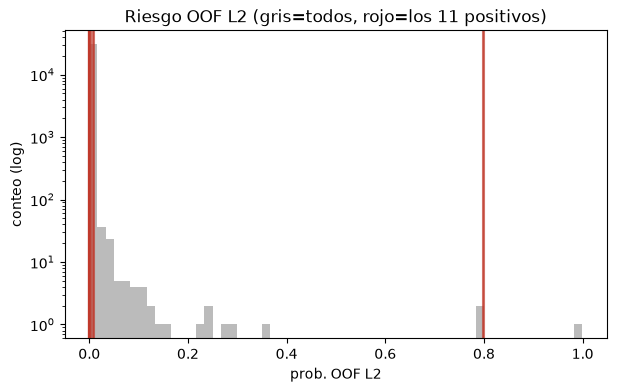

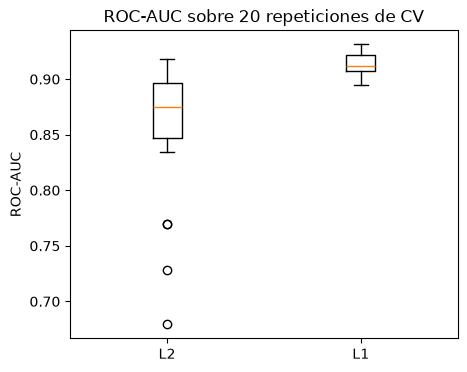

In [6]:
# --- Plots ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(oof_l2, bins=60, color="#bbb", log=True)
for i in np.where(y_l2 == 1)[0]:
    ax.axvline(oof_l2[i], color="#c0392b", alpha=0.7)
ax.set_title("Riesgo OOF L2 (gris=todos, rojo=los 11 positivos)")
ax.set_xlabel("prob. OOF L2"); ax.set_ylabel("conteo (log)")
b64_hist = fig_b64(fig)

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot([roc_l2, roc_l1], tick_labels=["L2", "L1"])
ax.set_title(f"ROC-AUC sobre {N_REPEATS} repeticiones de CV")
ax.set_ylabel("ROC-AUC")
b64_box = fig_b64(fig)

## Reporte HTML + resumen

In [7]:
lopo_rows = "".join(
    f"<tr><td>{k+1}</td><td>{prob:.4f}</td><td>{pct:.2f}%</td>"
    f"<td>{'sí' if y_l1[idx]==1 else 'no'}</td><td>{df.loc[idx,'region_name']}</td>"
    f"<td>{df.loc[idx,'superficie_quemada_total_ha']:.0f}</td></tr>"
    for k, (idx, prob, pct) in enumerate(sorted(lopo, key=lambda r: -r[2]))
)

html = f"""<html><head><meta charset="utf-8"><title>L2 Robust Eval</title>
<style>body{{font-family:sans-serif;margin:2rem;color:#222;max-width:1100px}}
table{{border-collapse:collapse;margin:1rem 0;width:100%}}th,td{{border:1px solid #ccc;padding:6px;text-align:left}}
th{{background:#f4f4f4}}h2{{border-bottom:1px solid #ccc;padding-bottom:.3rem;margin-top:2rem}}
.k{{color:#c0392b;font-weight:bold}}.flex{{display:flex;gap:2rem}}.flex>div{{flex:1}}img{{max-width:100%}}</style></head><body>
<h1>Evaluación robusta de L2 (clase rara) + proxy L1→L2</h1>
<p>2012-2018, {len(df)} filas usables. <b>L2 = {y_l2.sum()} positivos</b> (prevalencia {prev_l2:.5f}) · L1 = {y_l1.sum()}.
Modelo XGBoost idéntico a <code>modeling/02</code>. CV estratificada repetida {N_REPEATS}×{N_SPLITS}.</p>

<h2>A.1 — ROC/PR-AUC con intervalo de confianza (95%)</h2>
<table><tr><th>Modelo</th><th>ROC-AUC media</th><th>ROC-AUC IC95%</th><th>PR-AUC media</th><th>PR-AUC IC95%</th><th>PR-AUC base (prev.)</th></tr>
<tr><td>L2 (intensidad)</td><td class="k">{roc_l2_m:.3f}</td><td>[{roc_l2_lo:.3f}, {roc_l2_hi:.3f}]</td><td class="k">{pr_l2_m:.3f}</td><td>[{pr_l2_lo:.3f}, {pr_l2_hi:.3f}]</td><td>{prev_l2:.5f}</td></tr>
<tr><td>L1 (área)</td><td>{roc_l1_m:.3f}</td><td>[{roc_l1_lo:.3f}, {roc_l1_hi:.3f}]</td><td>{pr_l1_m:.3f}</td><td>[{pr_l1_lo:.3f}, {pr_l1_hi:.3f}]</td><td>{y_l1.mean():.5f}</td></tr></table>
<p>El IC ancho de L2 refleja la varianza por tener pocos positivos: es la lectura honesta del rendimiento.</p>
<div class="flex"><div><img src="data:image/png;base64,{b64_box}"></div><div><img src="data:image/png;base64,{b64_hist}"></div></div>

<h2>A.2 — Métricas por ranking (OOF L2)</h2>
<table><tr><th>Métrica</th><th>Valor</th></tr>
<tr><td>Recall@top-1% de riesgo</td><td>{rk[1]:.2f} ({round(rk[1]*y_l2.sum())}/{y_l2.sum()})</td></tr>
<tr><td>Recall@top-5%</td><td>{rk[5]:.2f} ({round(rk[5]*y_l2.sum())}/{y_l2.sum()})</td></tr>
<tr><td>Recall@top-10%</td><td>{rk[10]:.2f} ({round(rk[10]*y_l2.sum())}/{y_l2.sum()})</td></tr>
<tr><td>Percentiles de riesgo de los {y_l2.sum()} positivos</td><td>{', '.join(f'{p:.1f}' for p in pos_pct)}</td></tr></table>

<h2>A.3 — Leave-One-Positive-Out</h2>
<p>Cada positivo se deja fuera del entrenamiento; se reporta en qué percentil de riesgo lo ubica el modelo entrenado sin él.</p>
<table><tr><th>#</th><th>prob</th><th>percentil de riesgo</th><th>¿también L1 (área≥1000)?</th><th>región</th><th>ha</th></tr>{lopo_rows}</table>

<h2>C — ¿Sirve L1 (área) como proxy de L2 (intensidad)?</h2>
<table><tr><th>Test</th><th>Valor</th><th>Lectura</th></tr>
<tr><td>AUC del score L1 para predecir L2</td><td class="k">{proxy_auc:.3f}</td><td>vs AUC propio de L2 = {roc_l2_m:.3f}</td></tr>
<tr><td>PR-AUC del score L1 para L2</td><td>{proxy_pr:.3f}</td><td>vs L2 propio = {pr_l2_m:.3f}</td></tr>
<tr><td>Recall@top-5% usando score L1</td><td>{rk_proxy[5]:.2f}</td><td>vs L2 propio = {rk[5]:.2f}</td></tr>
<tr><td>Spearman(score L1, score L2)</td><td>{rho:.3f}</td><td>acuerdo de las dos superficies de riesgo</td></tr>
<tr><td>L2 que además son L1 (área≥1000)</td><td>{overlap} / {y_l2.sum()}</td><td>overlap directo de etiquetas</td></tr></table>
<p>Si el AUC del score L1 para L2 es cercano al AUC propio de L2 y el overlap es alto → L1 es un proxy razonable.
Si es bajo → área e intensidad son señales distintas y L1 no reemplaza a L2.</p>
</body></html>"""
OUT_HTML.write_text(html, encoding="utf-8")

print("\n=== RESUMEN ===")
print(f"L2 ROC-AUC: {roc_l2_m:.3f}  IC95% [{roc_l2_lo:.3f}, {roc_l2_hi:.3f}]")
print(f"L2 PR-AUC : {pr_l2_m:.3f}  IC95% [{pr_l2_lo:.3f}, {pr_l2_hi:.3f}]  (base {prev_l2:.5f})")
print(f"L2 recall@5% = {rk[5]:.2f} | percentiles positivos: {[round(p,1) for p in pos_pct]}")
print(f"Proxy L1->L2: AUC {proxy_auc:.3f} (L2 propio {roc_l2_m:.3f}) | Spearman {rho:.3f} | overlap {overlap}/{y_l2.sum()}")
print(f"\n✅ Reporte: {OUT_HTML}")


=== RESUMEN ===
L2 ROC-AUC: 0.854  IC95% [0.703, 0.916]
L2 PR-AUC : 0.094  IC95% [0.003, 0.139]  (base 0.00036)
L2 recall@5% = 0.64 | percentiles positivos: [np.float64(100.0), np.float64(100.0), np.float64(99.5), np.float64(99.4), np.float64(99.0), np.float64(98.0), np.float64(95.5), np.float64(94.6), np.float64(92.9), np.float64(58.3), np.float64(56.6)]
Proxy L1->L2: AUC 0.890 (L2 propio 0.854) | Spearman 0.492 | overlap 6/11

✅ Reporte: /home/imorales/Desktop/XAI/XAI-project/eda/L2_Robust_Eval_Report.html
